In [1]:
from google.colab import drive
import os

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


##Loading and preprocessing the images

In [4]:
import cv2
import numpy as np

In [5]:
base_dir='/content/drive/MyDrive/BUSI/Dataset_BUSI_with_GT'
classes=['normal','benign','malignant']
IMG_SIZE=128

In [10]:
image_list=[]
label_list=[]

print("Loading and converting images to arrays...")

Loading and converting images to arrays...


In [11]:
for label_idx, class_name in enumerate(classes):
    class_dir = os.path.join(base_dir, class_name)

    if not os.path.exists(class_dir):
        print(f"Warning: Could not find folder {class_dir}")
        continue

    for img_name in os.listdir(class_dir):

        if img_name.endswith('.png') and 'mask' not in img_name:
            img_path = os.path.join(class_dir, img_name)

            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0

                image_list.append(img)
                label_list.append(label_idx)

# Converting our lists into the final X and y NumPy arrays
X = np.array(image_list)
y = np.array(label_list)

print("--- Loading Complete ---")
print(f"Total images loaded: {len(X)}")

--- Loading Complete ---
Total images loaded: 780


In [12]:
print(f"Shape of X data: {X.shape}")

Shape of X data: (780, 128, 128, 3)


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [17]:
X_train,X_temp,y_train,y_temp=train_test_split(
    X,y,test_size=0.30,random_state=42,stratify=y
    )

In [18]:
X_val,X_test,y_val,y_test=train_test_split(
    X_test,y_test,test_size=0.50,random_state=42,stratify=y_temp
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 546
Validation samples: 117
Testing samples: 117


##Model


In [26]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


In [27]:
weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Manually forcing it into a strict dictionary format for TensorFlow
class_weight_dict = {
    0: weights_array[0], # Normal
    1: weights_array[1], # Benign
    2: weights_array[2]  # Malignant
}
print(f"Verified Dictionary: {class_weight_dict}")

Verified Dictionary: {0: np.float64(1.956989247311828), 1: np.float64(0.5947712418300654), 2: np.float64(1.2380952380952381)}


In [22]:
def build_baseline_cnn():
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(128, 128, 3)),

        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),


        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [23]:
print("Building Model A (No Augmentation)...")
model_a = build_baseline_cnn()

Building Model A (No Augmentation)...


In [28]:
print("Starting Training...")

history_a = model_a.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    verbose=1
)
print("--- Model A Training Complete ---")

Starting Training...
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 241ms/step - accuracy: 0.4212 - loss: 1.1356 - val_accuracy: 0.5556 - val_loss: 1.0422
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4707 - loss: 1.0962 - val_accuracy: 0.5556 - val_loss: 1.0092
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5385 - loss: 1.0381 - val_accuracy: 0.5385 - val_loss: 0.9939
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5769 - loss: 0.9881 - val_accuracy: 0.6154 - val_loss: 0.9021
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6319 - loss: 0.8270 - val_accuracy: 0.6325 - val_loss: 0.8259
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6996 - loss: 0.7647 - val_accuracy: 0.6581 - val_loss: 0.8479
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7070 - loss: 0.6578 - val_accuracy: 0.5299 - val_loss: 1.0272
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7418 - loss: 0.5584 - v

##Data Augmentation


In [29]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

In [45]:
print("Building Model B (WITH Augmentation)...")
model_b = tf.keras.Sequential([
    data_augmentation,
    build_baseline_cnn()
])

Building Model B (WITH Augmentation)...


In [46]:
model_b.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

In [47]:
print("Starting Training for Model B...")
history_b = model_b.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    verbose=1
)
print("--- Model B Training Complete ---")

Starting Training for Model B...
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.3901 - loss: 1.1203 - val_accuracy: 0.5043 - val_loss: 1.0942
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4908 - loss: 1.0950 - val_accuracy: 0.4017 - val_loss: 1.0727
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4451 - loss: 1.0380 - val_accuracy: 0.5812 - val_loss: 0.9375
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5092 - loss: 1.0092 - val_accuracy: 0.5299 - val_loss: 1.0206
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5879 - loss: 0.9825 - val_accuracy: 0.5897 - val_loss: 0.8539
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5897 - loss: 0.9187 - val_accuracy: 0.5214 - val_loss: 0.9973
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4982 - loss: 0.9499 - val_accuracy: 0.5556 - val_loss: 0.9854
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5275 - loss: 

##Copmparision

In [48]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


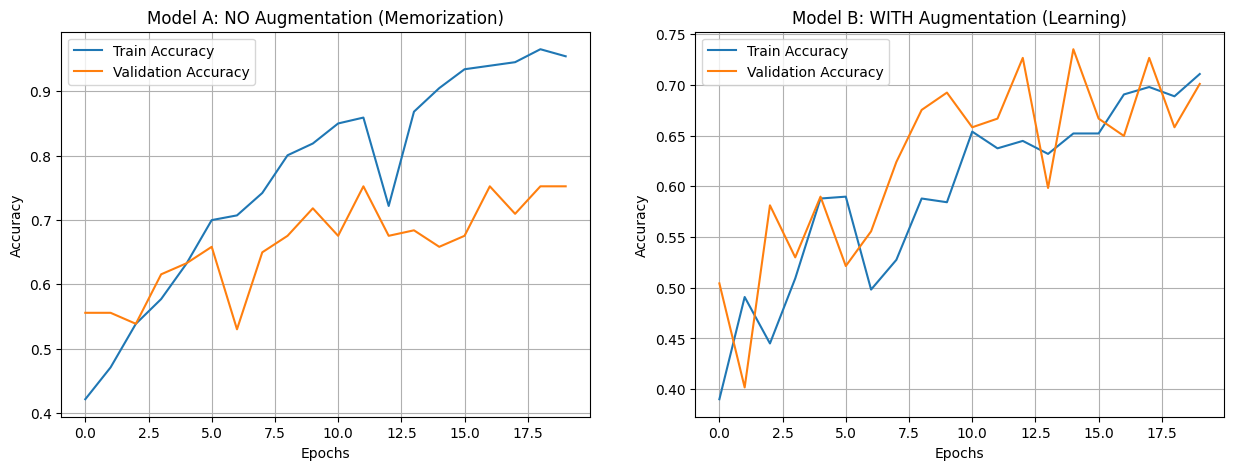

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history_a.history['accuracy'], label='Train Accuracy')
ax1.plot(history_a.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model A: NO Augmentation (Memorization)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_b.history['accuracy'], label='Train Accuracy')
ax2.plot(history_b.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Model B: WITH Augmentation (Learning)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.show()


EVALUATING ON UNSEEN TEST DATA (The Final Exam)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

Classification Report (Model B):
              precision    recall  f1-score   support

      normal       0.50      0.80      0.62        20
      benign       0.82      0.77      0.80        66
   malignant       0.83      0.61      0.70        31

    accuracy                           0.74       117
   macro avg       0.72      0.73      0.71       117
weighted avg       0.77      0.74      0.74       117



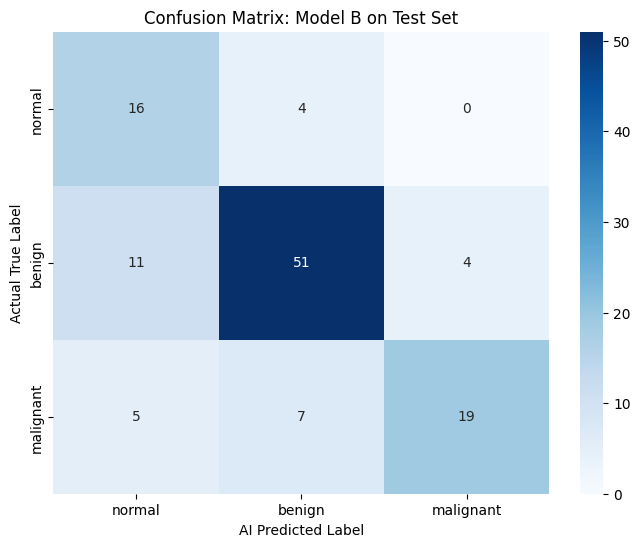

In [50]:
print("\n" + "="*50)
print("EVALUATING ON UNSEEN TEST DATA (The Final Exam)")
print("="*50)

predictions_b = model_b.predict(X_test)

y_pred_b = np.argmax(predictions_b, axis=1)

print("\nClassification Report (Model B):")
print(classification_report(y_test, y_pred_b, target_names=classes))

cm = confusion_matrix(y_test, y_pred_b)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: Model B on Test Set')
plt.ylabel('Actual True Label')
plt.xlabel('AI Predicted Label')
plt.show()

Resuming Training for Model B (Epochs 21-40)...
Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6996 - loss: 0.6487 - val_accuracy: 0.7009 - val_loss: 0.8785
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6941 - loss: 0.6357 - val_accuracy: 0.7094 - val_loss: 0.8948
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7381 - loss: 0.6007 - val_accuracy: 0.7436 - val_loss: 0.9235
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7564 - loss: 0.5824 - val_accuracy: 0.7350 - val_loss: 1.0095
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7381 - loss: 0.6128 - val_accuracy: 0.6581 - val_loss: 1.1023
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7436 - loss: 0.5804 - val_accuracy: 0.7179 - val_loss: 1.0101
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7637 - loss: 0.5174 - val_accuracy: 0.6838 - val_loss: 1.0346
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 

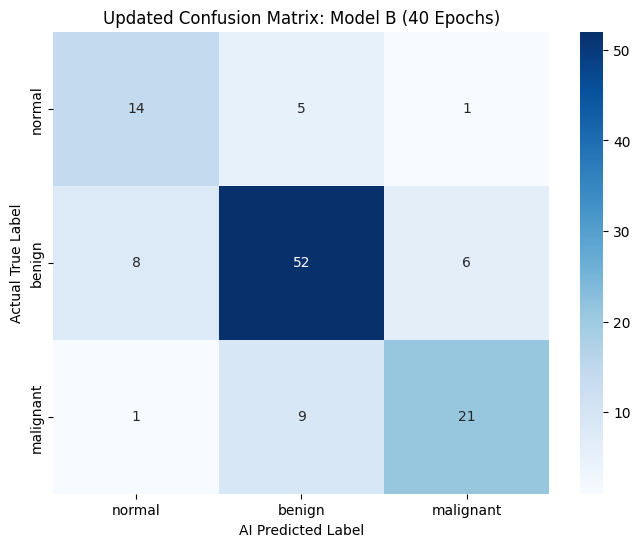

In [51]:
print("Resuming Training for Model B (Epochs 21-50)...")

history_b_continued = model_b.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    verbose=1
)

print("\n" + "="*50)
print("NEW EVALUATION ON TEST DATA (After 50 Total Epochs)")
print("="*50)

predictions_b_new = model_b.predict(X_test)
y_pred_b_new = np.argmax(predictions_b_new, axis=1)


print("\nUpdated Classification Report (Model B - 50 Epochs):")
print(classification_report(y_test, y_pred_b_new, target_names=classes))

cm_new = confusion_matrix(y_test, y_pred_b_new)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Updated Confusion Matrix: Model B (40 Epochs)')
plt.ylabel('Actual True Label')
plt.xlabel('AI Predicted Label')
plt.show()